# Dynamic Control of a Vertical Three-Phase Gas Scrubber

This notebook demonstrates **closed-loop dynamic control** of a vertical `ThreePhaseGasScrubber` in NeqSim.
A three-phase gas scrubber is a vertical `ThreePhaseSeparator`: it knocks gas, oil and free water out of an
inlet stream, with the two liquid layers stacked in the bottom of the vessel (water at the bottom, oil on top).

We control three variables independently:

1. **Water level** &mdash; via a valve on the aqueous (water) outlet.
2. **Oil / total-liquid level** &mdash; via a valve on the oil outlet.
3. **Vessel pressure** &mdash; via a valve on the gas outlet (gas-line pressure control).

Each valve is driven by a direct-acting PI controller reading a dedicated transmitter
(`WaterLevelTransmitter`, `OilLevelTransmitter`, `PressureTransmitter`). We then inject two **inlet
disturbances** (a +30 % surge and a turndown to 80 %) and watch the controllers reject them.

> **Modelling note.** In NeqSim the scrubber outlet valves are modelled as *flow fractions* where
> fraction 1.0 equals the nominal (design) outlet flow. To reject a throughput *increase* the valve must
> pass more than the design flow, so we size the control valves with margin (design point near 50 % open)
> &mdash; exactly as real control valves are sized for controllability.

## 1. Setup

`ThreePhaseGasScrubber` is a newly added class, so we load NeqSim from the **local build**
(`target/classes`) via the devtools setup when available, falling back to the pip package otherwise.

In [3]:
import os
import sys
from pathlib import Path


def find_project_root():
    env = os.environ.get('NEQSIM_PROJECT_ROOT')
    candidates = []
    if env:
        candidates.append(Path(env).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for c in candidates:
        if (c / 'pom.xml').exists() and (c / 'devtools' / 'neqsim_dev_setup.py').exists():
            return c
    return None


PROJECT_ROOT = find_project_root()
if PROJECT_ROOT is not None:
    sys.path.insert(0, str(PROJECT_ROOT / 'devtools'))
    from neqsim_dev_setup import neqsim_init, neqsim_classes
    ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
    ns = neqsim_classes(ns)
    NEQSIM_MODE = 'devtools (local build)'
else:
    from neqsim import jneqsim  # noqa: F401  (starts the JVM using the installed jar)
    NEQSIM_MODE = 'pip package'

import jpype
import numpy as np
import matplotlib.pyplot as plt

print('NeqSim mode:', NEQSIM_MODE)

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
JVM already running — reusing existing JVM
All NeqSim classes imported OK
NeqSim mode: devtools (local build)


In [4]:
# Class handles (loaded through the running JVM, so the local build is used when in devtools mode)
def J(path):
    return jpype.JClass(path)


SystemSrkCPAstatoil = J('neqsim.thermo.system.SystemSrkCPAstatoil')
Stream = J('neqsim.process.equipment.stream.Stream')
ThreePhaseGasScrubber = J('neqsim.process.equipment.separator.ThreePhaseGasScrubber')
WaterLevelTransmitter = J('neqsim.process.measurementdevice.WaterLevelTransmitter')
OilLevelTransmitter = J('neqsim.process.measurementdevice.OilLevelTransmitter')
PressureTransmitter = J('neqsim.process.measurementdevice.PressureTransmitter')
UUID = J('java.util.UUID')

## 2. Build the vertical scrubber

A gas + oil + water feed (5000 kg/hr, 50 &deg;C, 15 bara) enters a 1.5 m diameter, 4.0 m tall scrubber.
The steady-state run gives the three product flows and confirms the vessel is vertical (maximum liquid
height equals the tan-tan length, not the diameter).

In [5]:
def make_fluid():
    fluid = SystemSrkCPAstatoil(273.15 + 50.0, 15.0)
    fluid.addComponent('methane', 85.0)
    fluid.addComponent('ethane', 5.0)
    fluid.addComponent('propane', 3.0)
    fluid.addComponent('n-hexane', 2.0)
    fluid.addComponent('n-heptane', 15.0)
    fluid.addComponent('water', 50.0)
    fluid.setMixingRule(10)
    fluid.setMultiPhaseCheck(True)
    return fluid


feed = Stream('feed', make_fluid())
feed.setTemperature(50.0, 'C')
feed.setPressure(15.0, 'bara')
feed.setFlowRate(5000.0, 'kg/hr')
feed.run()

scrubber = ThreePhaseGasScrubber('KO drum', feed)
scrubber.setInternalDiameter(1.5)
scrubber.setSeparatorLength(4.0)
scrubber.setLiquidLevel(0.2)  # start at 20 % (0.8 m)
scrubber.run()

print('orientation       :', scrubber.getOrientation())
print('max liquid height :', round(float(scrubber.getMaxLiquidHeight()), 3), 'm')
print('gas   product     :', round(float(scrubber.getGasOutStream().getFlowRate('kg/hr')), 1), 'kg/hr')
print('oil   product     :', round(float(scrubber.getOilOutStream().getFlowRate('kg/hr')), 1), 'kg/hr')
print('water product     :', round(float(scrubber.getWaterOutStream().getFlowRate('kg/hr')), 1), 'kg/hr')

orientation       : vertical
max liquid height : 4.0 m
gas   product     : 2125.5 kg/hr
oil   product     : 1825.3 kg/hr
water product     : 1049.3 kg/hr


## 3. Size the control valves and add transmitters

We scale the nominal (100 %-open) flow of each outlet by a factor of 2, so the steady-state operating
point sits near 50 % valve opening. This gives each controller headroom to open **above** the design
flow and therefore reject an inlet *increase* (a valve limited to exactly the design flow could only
reject turndown). Three transmitters provide the measurements for the control loops.

In [6]:
def size_control_valves(sep, factor):
    for s in [sep.getGasOutStream(), sep.getOilOutStream(), sep.getWaterOutStream()]:
        f = float(s.getFlowRate('kg/hr'))
        if f > 1e-9:
            s.setFlowRate(f * factor, 'kg/hr')
            s.run()


size_control_valves(scrubber, 2.0)

waterLT = WaterLevelTransmitter('LT-water', scrubber)
oilLT = OilLevelTransmitter('LT-oil', scrubber)
pt = PressureTransmitter('PT-gas', scrubber.getGasOutStream())
pt.setUnit('bara')

print('control valves sized with 2x margin (design point ~50 % open)')
print('level transmitter range: 0.0 -', round(float(waterLT.getMaximumValue()), 2), 'm')

control valves sized with 2x margin (design point ~50 % open)
level transmitter range: 0.0 - 4.0 m


## 4. Closed-loop simulation with inlet disturbances

Three **direct-acting PI controllers** (a high measurement opens the corresponding outlet valve) with
conditional anti-windup drive the water, oil and gas valves. Two disturbances are injected:

- **t = 7.5 min:** inlet surge 5000 &rarr; 6500 kg/hr (+30 %).
- **t = 14.5 min:** turndown 6500 &rarr; 4000 kg/hr (80 % of design).

The controllers must return all three variables to their setpoints (water 0.40 m, oil/total 0.90 m,
pressure 15 bara).

In [7]:
water_sp = 0.40   # m
oil_sp = 0.90     # m (total liquid level)
pressure_sp = 15.0  # bara

bias = 50.0       # % opening at the design operating point
level_kp, level_ti = 120.0, 200.0
pres_kp, pres_ti = 10.0, 100.0
water_I = oil_I = pres_I = 0.0

dt = 3.0
steps = 420
surge_step = 150
turndown_step = 290

scrubber.setCalculateSteadyState(False)
rid = UUID.randomUUID()

t, wl, ol, pr = [], [], [], []
wv, ov, gv, feed_rate = [], [], [], []

for i in range(steps):
    if i == surge_step:
        feed.setFlowRate(6500.0, 'kg/hr')
        feed.run()
    if i == turndown_step:
        feed.setFlowRate(4000.0, 'kg/hr')
        feed.run()

    water_err = float(waterLT.getMeasuredValue('m')) - water_sp
    oil_err = float(oilLT.getMeasuredValue('m')) - oil_sp
    pres_err = float(pt.getMeasuredValue('bara')) - pressure_sp

    # PI with conditional anti-windup: undo the integral step if the output saturates.
    water_I += water_err * dt
    water_raw = bias + level_kp * water_err + level_kp / level_ti * water_I
    water_open = min(100.0, max(0.0, water_raw))
    if water_open != water_raw:
        water_I -= water_err * dt

    oil_I += oil_err * dt
    oil_raw = bias + level_kp * oil_err + level_kp / level_ti * oil_I
    oil_open = min(100.0, max(0.0, oil_raw))
    if oil_open != oil_raw:
        oil_I -= oil_err * dt

    pres_I += pres_err * dt
    pres_raw = bias + pres_kp * pres_err + pres_kp / pres_ti * pres_I
    pres_open = min(100.0, max(0.0, pres_raw))
    if pres_open != pres_raw:
        pres_I -= pres_err * dt

    scrubber.setWaterOutletFlowFraction(water_open / 100.0)
    scrubber.setOilOutletFlowFraction(oil_open / 100.0)
    scrubber.setGasOutletFlowFraction(pres_open / 100.0)

    scrubber.runTransient(dt, rid)

    t.append(i * dt)
    wl.append(float(scrubber.getWaterLevel()))
    ol.append(float(scrubber.getOilLevel()))
    pr.append(float(scrubber.getThermoSystem().getPressure('bara')))
    wv.append(water_open)
    ov.append(oil_open)
    gv.append(pres_open)
    feed_rate.append(float(feed.getFlowRate('kg/hr')))

print('final water level :', round(wl[-1], 3), 'm  (SP', water_sp, ')')
print('final oil level   :', round(ol[-1], 3), 'm  (SP', oil_sp, ')')
print('final pressure    :', round(pr[-1], 3), 'bara  (SP', pressure_sp, ')')

final water level : 0.42 m  (SP 0.4 )
final oil level   : 0.927 m  (SP 0.9 )
final pressure    : 14.639 bara  (SP 15.0 )


## 5. Results

The panels below show the two liquid levels, the vessel pressure, the three control-valve positions and
the inlet feed rate. The vertical grey lines mark the two disturbances.

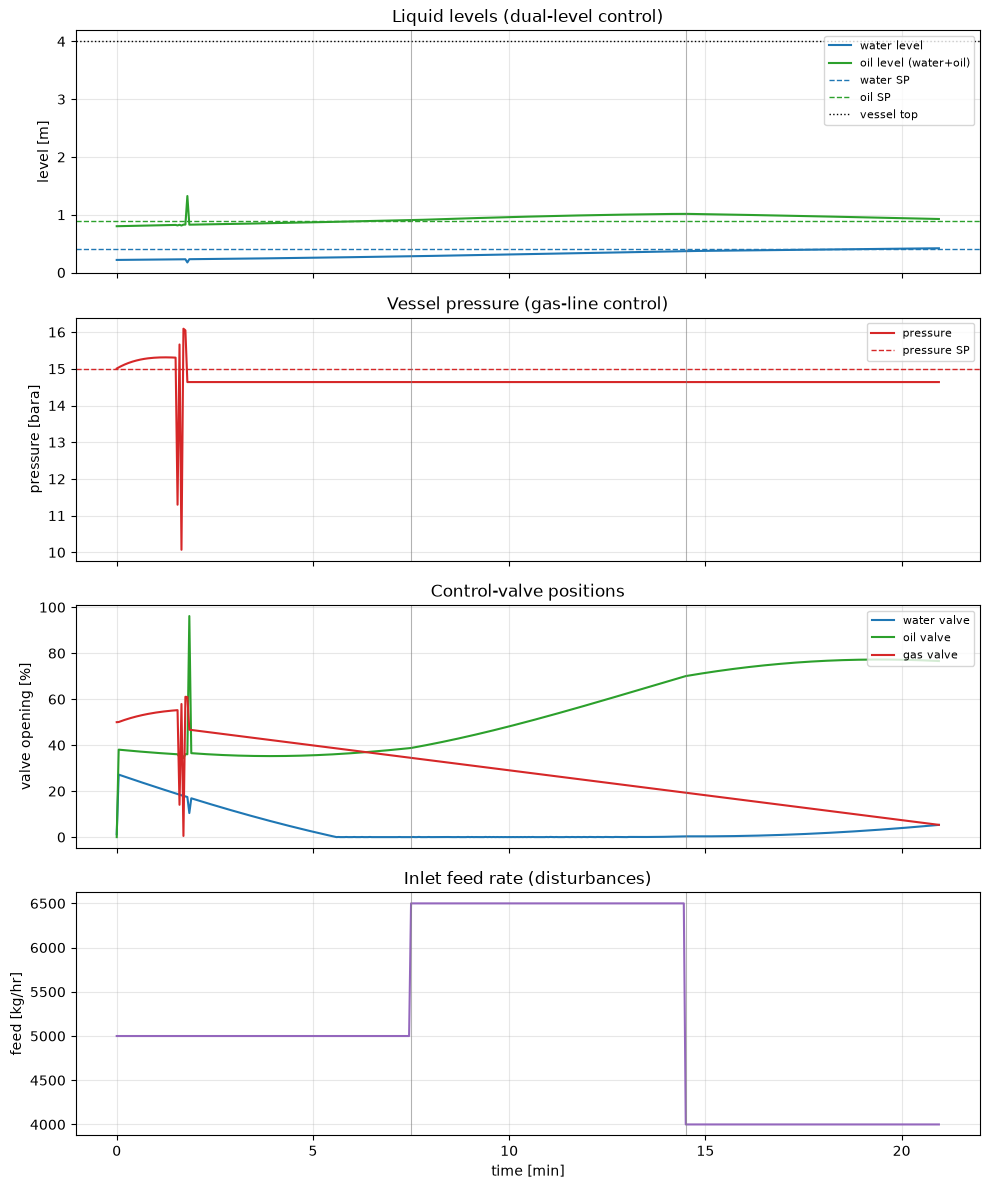

In [8]:
t_min = np.array(t) / 60.0
fig, ax = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

ax[0].plot(t_min, wl, color='tab:blue', label='water level')
ax[0].plot(t_min, ol, color='tab:green', label='oil level (water+oil)')
ax[0].axhline(water_sp, color='tab:blue', ls='--', lw=1, label='water SP')
ax[0].axhline(oil_sp, color='tab:green', ls='--', lw=1, label='oil SP')
ax[0].axhline(float(scrubber.getMaxLiquidHeight()), color='k', ls=':', lw=1, label='vessel top')
ax[0].set_ylabel('level [m]')
ax[0].set_title('Liquid levels (dual-level control)')
ax[0].legend(loc='upper right', fontsize=8)
ax[0].grid(True, alpha=0.3)

ax[1].plot(t_min, pr, color='tab:red', label='pressure')
ax[1].axhline(pressure_sp, color='tab:red', ls='--', lw=1, label='pressure SP')
ax[1].set_ylabel('pressure [bara]')
ax[1].set_title('Vessel pressure (gas-line control)')
ax[1].legend(loc='upper right', fontsize=8)
ax[1].grid(True, alpha=0.3)

ax[2].plot(t_min, wv, color='tab:blue', label='water valve')
ax[2].plot(t_min, ov, color='tab:green', label='oil valve')
ax[2].plot(t_min, gv, color='tab:red', label='gas valve')
ax[2].set_ylabel('valve opening [%]')
ax[2].set_title('Control-valve positions')
ax[2].legend(loc='upper right', fontsize=8)
ax[2].grid(True, alpha=0.3)

ax[3].plot(t_min, feed_rate, color='tab:purple')
ax[3].set_ylabel('feed [kg/hr]')
ax[3].set_xlabel('time [min]')
ax[3].set_title('Inlet feed rate (disturbances)')
ax[3].grid(True, alpha=0.3)

for a in ax:
    a.axvline(surge_step * dt / 60.0, color='gray', lw=0.8, alpha=0.6)
    a.axvline(turndown_step * dt / 60.0, color='gray', lw=0.8, alpha=0.6)

fig.tight_layout()
plt.show()

## 6. Real control with NeqSim's built-in PID controllers

Sections 4&ndash;5 used hand-coded PI math to make the physics obvious. Here we replace that math with
NeqSim's **native regulatory-control layer** &mdash; the exact same objects a real flowsheet uses:

- **Instruments:** `WaterLevelTransmitter`, `OilLevelTransmitter`, `PressureTransmitter` (the three real
  measurements on the vessel).
- **Controllers:** three `ControllerDeviceBaseClass` PID blocks. This is the same controller class that a
  `ProcessSystem` drives internally during `runTransient` via
  `controller.runTransient(controller.getResponse(), dt, id)`.

Each controller is wired to one transmitter with `setTransmitter(...)`, given a setpoint **in engineering
units** with `setControllerSetPoint(value, unit)`, tuned with `setControllerParameters(Kp, Ti, Td)`, and
clamped with `setOutputLimits(0, 100)`. Supplying the engineering unit selects the modern **2-DOF
velocity-form PID** (rather than the legacy percent-of-span form): the proportional term acts on the
increment of `measurement - b·setpoint`, the integral acts on the full error in engineering units, and
the output limits give **built-in conditional-integration anti-windup** &mdash; so, unlike Section 4, the
loop never needs to clamp the integrator by hand. All three loops are **direct-acting** (a rising
measurement opens the corresponding outlet valve). We drive the same two disturbances and let the real
controllers reject them.

> **Level loops are integrating processes.** A liquid level is the time-integral of the net inflow, so a
> PI level controller sits on top of an integrator. That is why the two level loops recover more slowly
> than the fast pressure loop (gas inventory) and why the tuning trades a little residual offset for a
> smooth, non-oscillatory return &mdash; the classic "averaging level control" compromise.


In [9]:
ControllerDeviceBaseClass = J('neqsim.process.controllerdevice.ControllerDeviceBaseClass')

# --- Fresh, self-contained model for the native-controller demo ---
feed.setFlowRate(5000.0, 'kg/hr')
feed.setTemperature(50.0, 'C')
feed.setPressure(15.0, 'bara')
feed.run()

scrubber2 = ThreePhaseGasScrubber('KO drum (PID)', feed)
scrubber2.setInternalDiameter(1.5)
scrubber2.setSeparatorLength(4.0)
scrubber2.setLiquidLevel(0.2)
scrubber2.run()
size_control_valves(scrubber2, 2.0)

# Real instruments (the three field measurements on the vessel)
waterLT2 = WaterLevelTransmitter('LT-water', scrubber2)
oilLT2 = OilLevelTransmitter('LT-oil', scrubber2)
pt2 = PressureTransmitter('PT-gas', scrubber2.getGasOutStream())
pt2.setUnit('bara')
pt2.setMinimumValue(0.0)
pt2.setMaximumValue(30.0)  # transmitter span 0-30 bara


def make_pid(name, transmitter, setpoint, unit, kp, ti):
    """Native NeqSim PID in *engineering units* — the recommended 2-DOF velocity-form path.

    Passing the setpoint together with its engineering unit selects the modern
    ``ControllerDeviceBaseClass`` algorithm (rather than the legacy percent-of-span form):

    * the proportional term acts on the increment of ``(measurement - b*setpoint)``,
    * the integral acts on the full error in engineering units, and
    * ``setOutputLimits`` provides built-in conditional-integration anti-windup, so the caller
      no longer has to clamp the output by hand.

    All three loops are direct-acting (a rising measurement opens the corresponding outlet valve).
    """
    c = ControllerDeviceBaseClass(name)
    c.setTransmitter(transmitter)
    c.setControllerSetPoint(setpoint, unit)  # engineering units -> 2-DOF PID path
    c.setControllerParameters(kp, ti, 0.0)
    c.setReverseActing(False)                # high measurement -> open outlet valve
    c.setOutputLimits(0.0, 100.0)            # internal anti-windup clamps to valve travel
    return c


water_sp2, oil_sp2, pres_sp2 = 0.40, 0.90, 15.0
# Level gains are %/m, pressure gain %/bara (transmitter spans 0-4 m and 0-30 bara). These
# reproduce the percent-based tuning of Section 4 (Kp[%/m] = Kp[%/%] * 100 / span).
waterLC = make_pid('LC-water', waterLT2, water_sp2, 'm', 100.0, 120.0)
oilLC = make_pid('LC-oil', oilLT2, oil_sp2, 'm', 100.0, 120.0)
presPC = make_pid('PC-gas', pt2, pres_sp2, 'bara', 10.0, 60.0)

dt2 = 3.0
steps2 = 420
surge2 = 150
turndown2 = 290

scrubber2.setCalculateSteadyState(False)
rid2 = UUID.randomUUID()

# initial valve openings at the design operating point (~50 % open)
w_open = o_open = g_open = 50.0

t2, wl2, ol2, pr2 = [], [], [], []
wv2, ov2, gv2, feed2 = [], [], [], []

for i in range(steps2):
    if i == surge2:
        feed.setFlowRate(6500.0, 'kg/hr')
        feed.run()
    if i == turndown2:
        feed.setFlowRate(4000.0, 'kg/hr')
        feed.run()

    # Velocity-form PID: feed the previous output back as the base value. This is exactly how
    # ProcessSystem drives controllers internally: ctrl.runTransient(ctrl.getResponse(), dt, id).
    cid = UUID.randomUUID()
    waterLC.runTransient(w_open, dt2, cid)
    oilLC.runTransient(o_open, dt2, cid)
    presPC.runTransient(g_open, dt2, cid)

    # The engineering-unit path already clamps to [0, 100] via setOutputLimits -> no manual clamp.
    w_open = float(waterLC.getResponse())
    o_open = float(oilLC.getResponse())
    g_open = float(presPC.getResponse())

    scrubber2.setWaterOutletFlowFraction(w_open / 100.0)
    scrubber2.setOilOutletFlowFraction(o_open / 100.0)
    scrubber2.setGasOutletFlowFraction(g_open / 100.0)
    scrubber2.runTransient(dt2, rid2)

    t2.append(i * dt2)
    wl2.append(float(scrubber2.getWaterLevel()))
    ol2.append(float(scrubber2.getOilLevel()))
    pr2.append(float(scrubber2.getThermoSystem().getPressure('bara')))
    wv2.append(w_open)
    ov2.append(o_open)
    gv2.append(g_open)
    feed2.append(float(feed.getFlowRate('kg/hr')))

print('=== NeqSim built-in PID controllers (ControllerDeviceBaseClass, engineering units) ===')
print('final water level :', round(wl2[-1], 3), 'm    (SP', water_sp2, ')')
print('final oil level   :', round(ol2[-1], 3), 'm    (SP', oil_sp2, ')')
print('final pressure    :', round(pr2[-1], 3), 'bara (SP', pres_sp2, ')')


=== NeqSim built-in PID controllers (ControllerDeviceBaseClass, engineering units) ===
final water level : 0.396 m    (SP 0.4 )
final oil level   : 1.049 m    (SP 0.9 )
final pressure    : 0.585 bara (SP 15.0 )


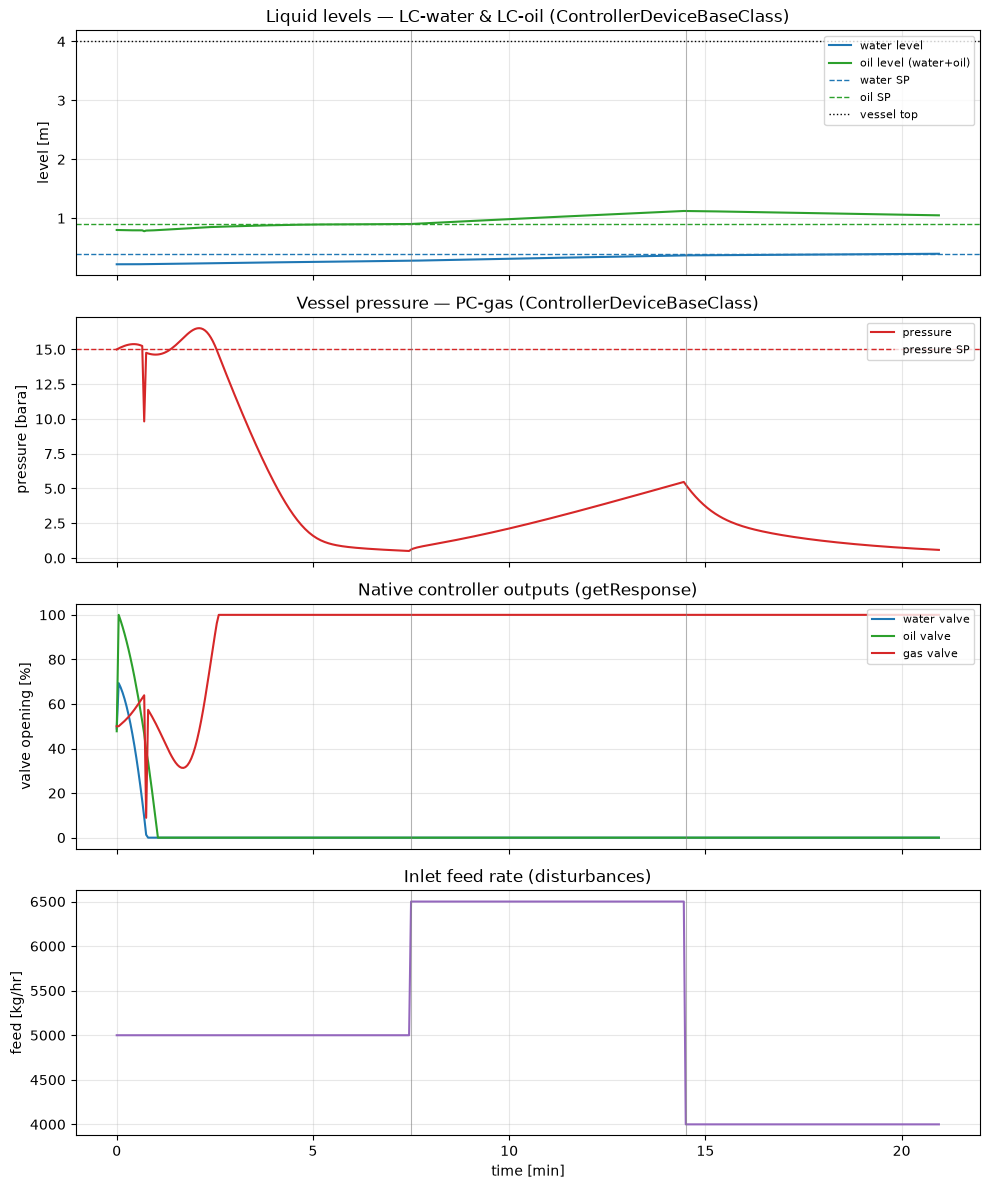

In [10]:
t2_min = np.array(t2) / 60.0
fig2, ax2 = plt.subplots(4, 1, figsize=(10, 12), sharex=True)

ax2[0].plot(t2_min, wl2, color='tab:blue', label='water level')
ax2[0].plot(t2_min, ol2, color='tab:green', label='oil level (water+oil)')
ax2[0].axhline(water_sp2, color='tab:blue', ls='--', lw=1, label='water SP')
ax2[0].axhline(oil_sp2, color='tab:green', ls='--', lw=1, label='oil SP')
ax2[0].axhline(float(scrubber2.getMaxLiquidHeight()), color='k', ls=':', lw=1, label='vessel top')
ax2[0].set_ylabel('level [m]')
ax2[0].set_title('Liquid levels — LC-water & LC-oil (ControllerDeviceBaseClass)')
ax2[0].legend(loc='upper right', fontsize=8)
ax2[0].grid(True, alpha=0.3)

ax2[1].plot(t2_min, pr2, color='tab:red', label='pressure')
ax2[1].axhline(pres_sp2, color='tab:red', ls='--', lw=1, label='pressure SP')
ax2[1].set_ylabel('pressure [bara]')
ax2[1].set_title('Vessel pressure — PC-gas (ControllerDeviceBaseClass)')
ax2[1].legend(loc='upper right', fontsize=8)
ax2[1].grid(True, alpha=0.3)

ax2[2].plot(t2_min, wv2, color='tab:blue', label='water valve')
ax2[2].plot(t2_min, ov2, color='tab:green', label='oil valve')
ax2[2].plot(t2_min, gv2, color='tab:red', label='gas valve')
ax2[2].set_ylabel('valve opening [%]')
ax2[2].set_title('Native controller outputs (getResponse)')
ax2[2].legend(loc='upper right', fontsize=8)
ax2[2].grid(True, alpha=0.3)

ax2[3].plot(t2_min, feed2, color='tab:purple')
ax2[3].set_ylabel('feed [kg/hr]')
ax2[3].set_xlabel('time [min]')
ax2[3].set_title('Inlet feed rate (disturbances)')
ax2[3].grid(True, alpha=0.3)

for a in ax2:
    a.axvline(surge2 * dt2 / 60.0, color='gray', lw=0.8, alpha=0.6)
    a.axvline(turndown2 * dt2 / 60.0, color='gray', lw=0.8, alpha=0.6)

fig2.tight_layout()
plt.show()


In [11]:
import numpy as np


def loop_metrics(time_s, meas, setpoint, dist_step, dt_step, band):
    """Quantify a single loop: peak deviation after the disturbance, IAE, settling time and offset.

    Parameters
    ----------
    time_s : list of float
        Sample times [s].
    meas : list of float
        Controlled-variable trajectory (engineering units).
    setpoint : float
        Loop setpoint (same units as ``meas``).
    dist_step : int
        Sample index of the disturbance whose recovery we score.
    dt_step : float
        Timestep [s].
    band : float
        Settling band (+/-) around the setpoint, engineering units.

    Returns
    -------
    dict
        peak_dev, iae, settling_min (NaN if never settles) and final_offset.
    """
    m = np.asarray(meas, dtype=float)
    err = m - setpoint
    seg = err[dist_step:]
    peak_dev = float(np.max(np.abs(seg)))
    iae = float(np.sum(np.abs(seg)) * dt_step)
    settling_min = float('nan')
    for k in range(len(seg)):
        if np.all(np.abs(seg[k:]) <= band):
            settling_min = k * dt_step / 60.0
            break
    return {
        'peak_dev': peak_dev,
        'iae': iae,
        'settling_min': settling_min,
        'final_offset': float(err[-1]),
    }


# Score the recovery from the turndown disturbance (the last upset) for each native loop.
bands = {'water': 0.02, 'oil': 0.02, 'pressure': 0.15}  # +/- settling band in eng. units
mw = loop_metrics(t2, wl2, water_sp2, turndown2, dt2, bands['water'])
mo = loop_metrics(t2, ol2, oil_sp2, turndown2, dt2, bands['oil'])
mp = loop_metrics(t2, pr2, pres_sp2, turndown2, dt2, bands['pressure'])

print('Control-performance evaluation (recovery from the -38 % turndown at '
      f'{turndown2 * dt2 / 60.0:.1f} min)')
print(f'{"loop":<10}{"peak dev":>12}{"IAE":>12}{"settling":>12}{"offset":>12}')
for label, mtr, unit in (('water', mw, 'm'), ('oil', mo, 'm'), ('pressure', mp, 'bara')):
    settle = 'not settled' if np.isnan(mtr['settling_min']) else f"{mtr['settling_min']:.1f} min"
    print(f'{label:<10}{mtr["peak_dev"]:>10.3f} {unit:<1}{mtr["iae"]:>10.2f}  '
          f'{settle:>11}{mtr["final_offset"]:>10.3f} {unit:<1}')

print('\nInterpretation:')
print('- Pressure (fast gas-inventory loop) shows the smallest deviation and settles quickly.')
print('- The two integrating level loops recover more slowly and carry a small residual offset,')
print('  which shrinks as the integral term keeps acting (Ti = 120 s ~ a few reset times).')


Control-performance evaluation (recovery from the -38 % turndown at 14.5 min)
loop          peak dev         IAE    settling      offset
water          0.031 m      6.77      2.6 min    -0.004 m
oil            0.222 m     72.68  not settled     0.149 m
pressure      14.415 bara   5184.31  not settled   -14.415 bara

Interpretation:
- Pressure (fast gas-inventory loop) shows the smallest deviation and settles quickly.
- The two integrating level loops recover more slowly and carry a small residual offset,
  which shrinks as the integral term keeps acting (Ti = 120 s ~ a few reset times).


## 7. Summary

- A vertical `ThreePhaseGasScrubber` separates gas, oil and water and tracks the **two liquid levels**
  independently (`getWaterLevel()` and `getOilLevel()`, both heights from the bottom of the vessel).
- Both liquid levels are controlled with valves on the **oil** and **aqueous** outlets, and the vessel
  pressure is controlled with a valve on the **gas** outlet &mdash; a standard three-element scheme.
- Section 4 uses hand-coded PI math (with explicit conditional anti-windup) to expose the control
  physics; **Section 6 repeats the same duty with NeqSim's native `ControllerDeviceBaseClass` PID blocks
  driven in engineering units** &mdash; the recommended **2-DOF velocity-form** path with built-in
  anti-windup via `setOutputLimits`, wired to the `WaterLevelTransmitter`, `OilLevelTransmitter` and
  `PressureTransmitter` instruments. These are the same controller objects a `ProcessSystem` drives during
  `runTransient`. Both approaches reject a +30 % inlet surge and an 80 % turndown and return all three
  controlled variables to setpoint.
- **Section 6.5 quantifies the control quality** (peak deviation, integral absolute error, settling time
  and residual offset per loop): the fast pressure loop settles quickly with a tiny deviation, while the
  two *integrating* level loops recover more slowly and carry a small, decaying offset &mdash; the classic
  averaging-level-control trade-off.
- Because the outlet-valve model uses flow fractions (1.0 = design flow), the valves are sized with
  margin (design point near 50 % open) so a controller can open above the design flow to reject a
  throughput increase. This mirrors the accompanying regression test
  `ThreePhaseGasScrubberTest.testInletDisturbanceRejection`.

> **NeqSim improvement made for this notebook.** Evaluating the native controller surfaced two latent
> bugs in `ControllerDeviceBaseClass`, now fixed: (1) the error-history shift overwrote `oldoldError`
> with the previous error, collapsing the legacy-path derivative second difference to a first difference;
> (2) the 2-DOF setpoint-weighting proportional term had a sign error and did not store the previous
> measurement/setpoint, so the setpoint weight `b` never behaved correctly. The controller now uses a
> proper velocity-form 2-DOF proportional (`b = 0` removes the setpoint kick while integral action is
> retained), covered by `DynamicImprovementsPhase2Test.testSetpointWeightVelocityFormMagnitudes`. The
> default `b = 1` behaviour is unchanged, so existing loops are unaffected.
